# UCI HAR Dataset 기반 CNN+GRU 분류
참고 논문 : A Multichannel CNN-GRU Model for Human Activity Recognition

해당 논문에서 제안한 멀티채널 UCI CNN-GRU 구조를 기반으로 HAR Dataset 분류를 진행한다.


In [ ]:
# 라이브러리 import
import numpy as np
import tensorflow as tf #딥러닝 프레임워크
import matplotlib.pyplot as plt # 학습 곡선 시각화(그래프)
import seaborn as sns #시각화

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Activation, BatchNormalization,
    MaxPooling1D, Concatenate, GRU, GlobalAveragePooling1D,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam #optimizer
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau #학습 도중 자동 제어 장치

from sklearn.metrics import classification_report, confusion_matrix #학습 후 성능 분석용

In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                # 1. 공백 정리
                # 2. 양끝 공백 제거
                # 3. 공백 기준으로 split -> 문자열 숫자 리스트로 변환
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # LSTM 입력 형태로 변환
    # (channels, samples, time) -> (samples, time, channels)
    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))

In [ ]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:

            # 문자열 형태의 숫자를 읽어서 공백 제거 후 정수로 변환
            y.append(int(row.strip()))

    # 리스트 -> numpy 배열로 변환
    y = np.array(y, dtype=np.int32)

    # 원래 라벨이 1~6이라서 딥러닝에서 사용하 0~5로 변경
    return y - 1

In [ ]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# (timesteps, features) 입력 구조
input_shape = (X_train.shape[1], X_train.shape[2])
# 분류할 동작 개수
num_classes = 6

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [ ]:
# 멀티채널 CNN 함수
# 서로 다른 kernel_size로 짧은/중간/긴 패턴을 추출
# 채널별 kernel_size = 3, 5, 7
# Conv1D -> ReLU -> BatchNorm -> Conv1D -> ReLU -> MaxPooling1D
def cnn_branch(inputs, kernel_size):
    x = Conv1D(
        filters=64,
        kernel_size=kernel_size,
        padding='same'
    )(inputs)
    x = Activation('relu')(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=128,
        kernel_size=kernel_size,
        padding='same'
    )(x)
    x = Activation('relu')(x)

    # 논문 설정: pool size = 2, stride = 1
    # 정보 손실을 최소화하면서 주변 특징을 요약
    x = MaxPooling1D(pool_size=2, strides=1, padding='same')(x)
    return x

# Input
# -> 3개 CNN 채널 (k=3,5,7)
# -> Concatenate 채널별 특징 결합
# -> GRU(128)
# -> GRU(64)
# -> GAP
# -> BatchNorm
# -> Dense(softmax)
inputs = Input(shape=input_shape)

branch_3 = cnn_branch(inputs, 3)  # 짧은 패턴
branch_5 = cnn_branch(inputs, 5)  # 중간 패턴
branch_7 = cnn_branch(inputs, 7)  # 긴 패턴

x = Concatenate(axis=-1)([branch_3, branch_5, branch_7])

# 첫 번째 GRU:
# CNN이 만든 시계열 특징을 입력받아 시간 흐름을 학습
x = GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.0)(x)

# 두 번째 GRU:
# 더 추상적인 시간 특징을 학습
x = GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0)(x)

x = GlobalAveragePooling1D()(x)
x = BatchNormalization()(x)

# 최종 분류층
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
            optimizer=Adam(learning_rate=0.001),
            # 정답이 정수 라벨 (0~5)일 때 사용하는 다중 분류용 손실 함수
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 64)   │      1,792 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 64)   │      2,944 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 128, 64)   │      4,096 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 128, 64)   │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 128, 64)   │          0 │ conv1d_8[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 128, 64)   │          0 │ conv1d_10[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ activation_6[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ activation_8[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ activation_10[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 128, 128)  │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 128, 128)  │     57,472 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 128)  │          0 │ conv1d_7[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 128, 128)  │          0 │ conv1d_9[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 128, 128)  │          0 │ conv1d_11[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 128, 128)  │          0 │ activation_7[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 128, 128)  │          0 │ activation_9[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 128, 128)  │          0 │ activation_11[0]

 Total params: 368,134 (1.40 MB)

 Trainable params: 367,622 (1.40 MB)

 Non-trainable params: 512 (2.00 KB)

None


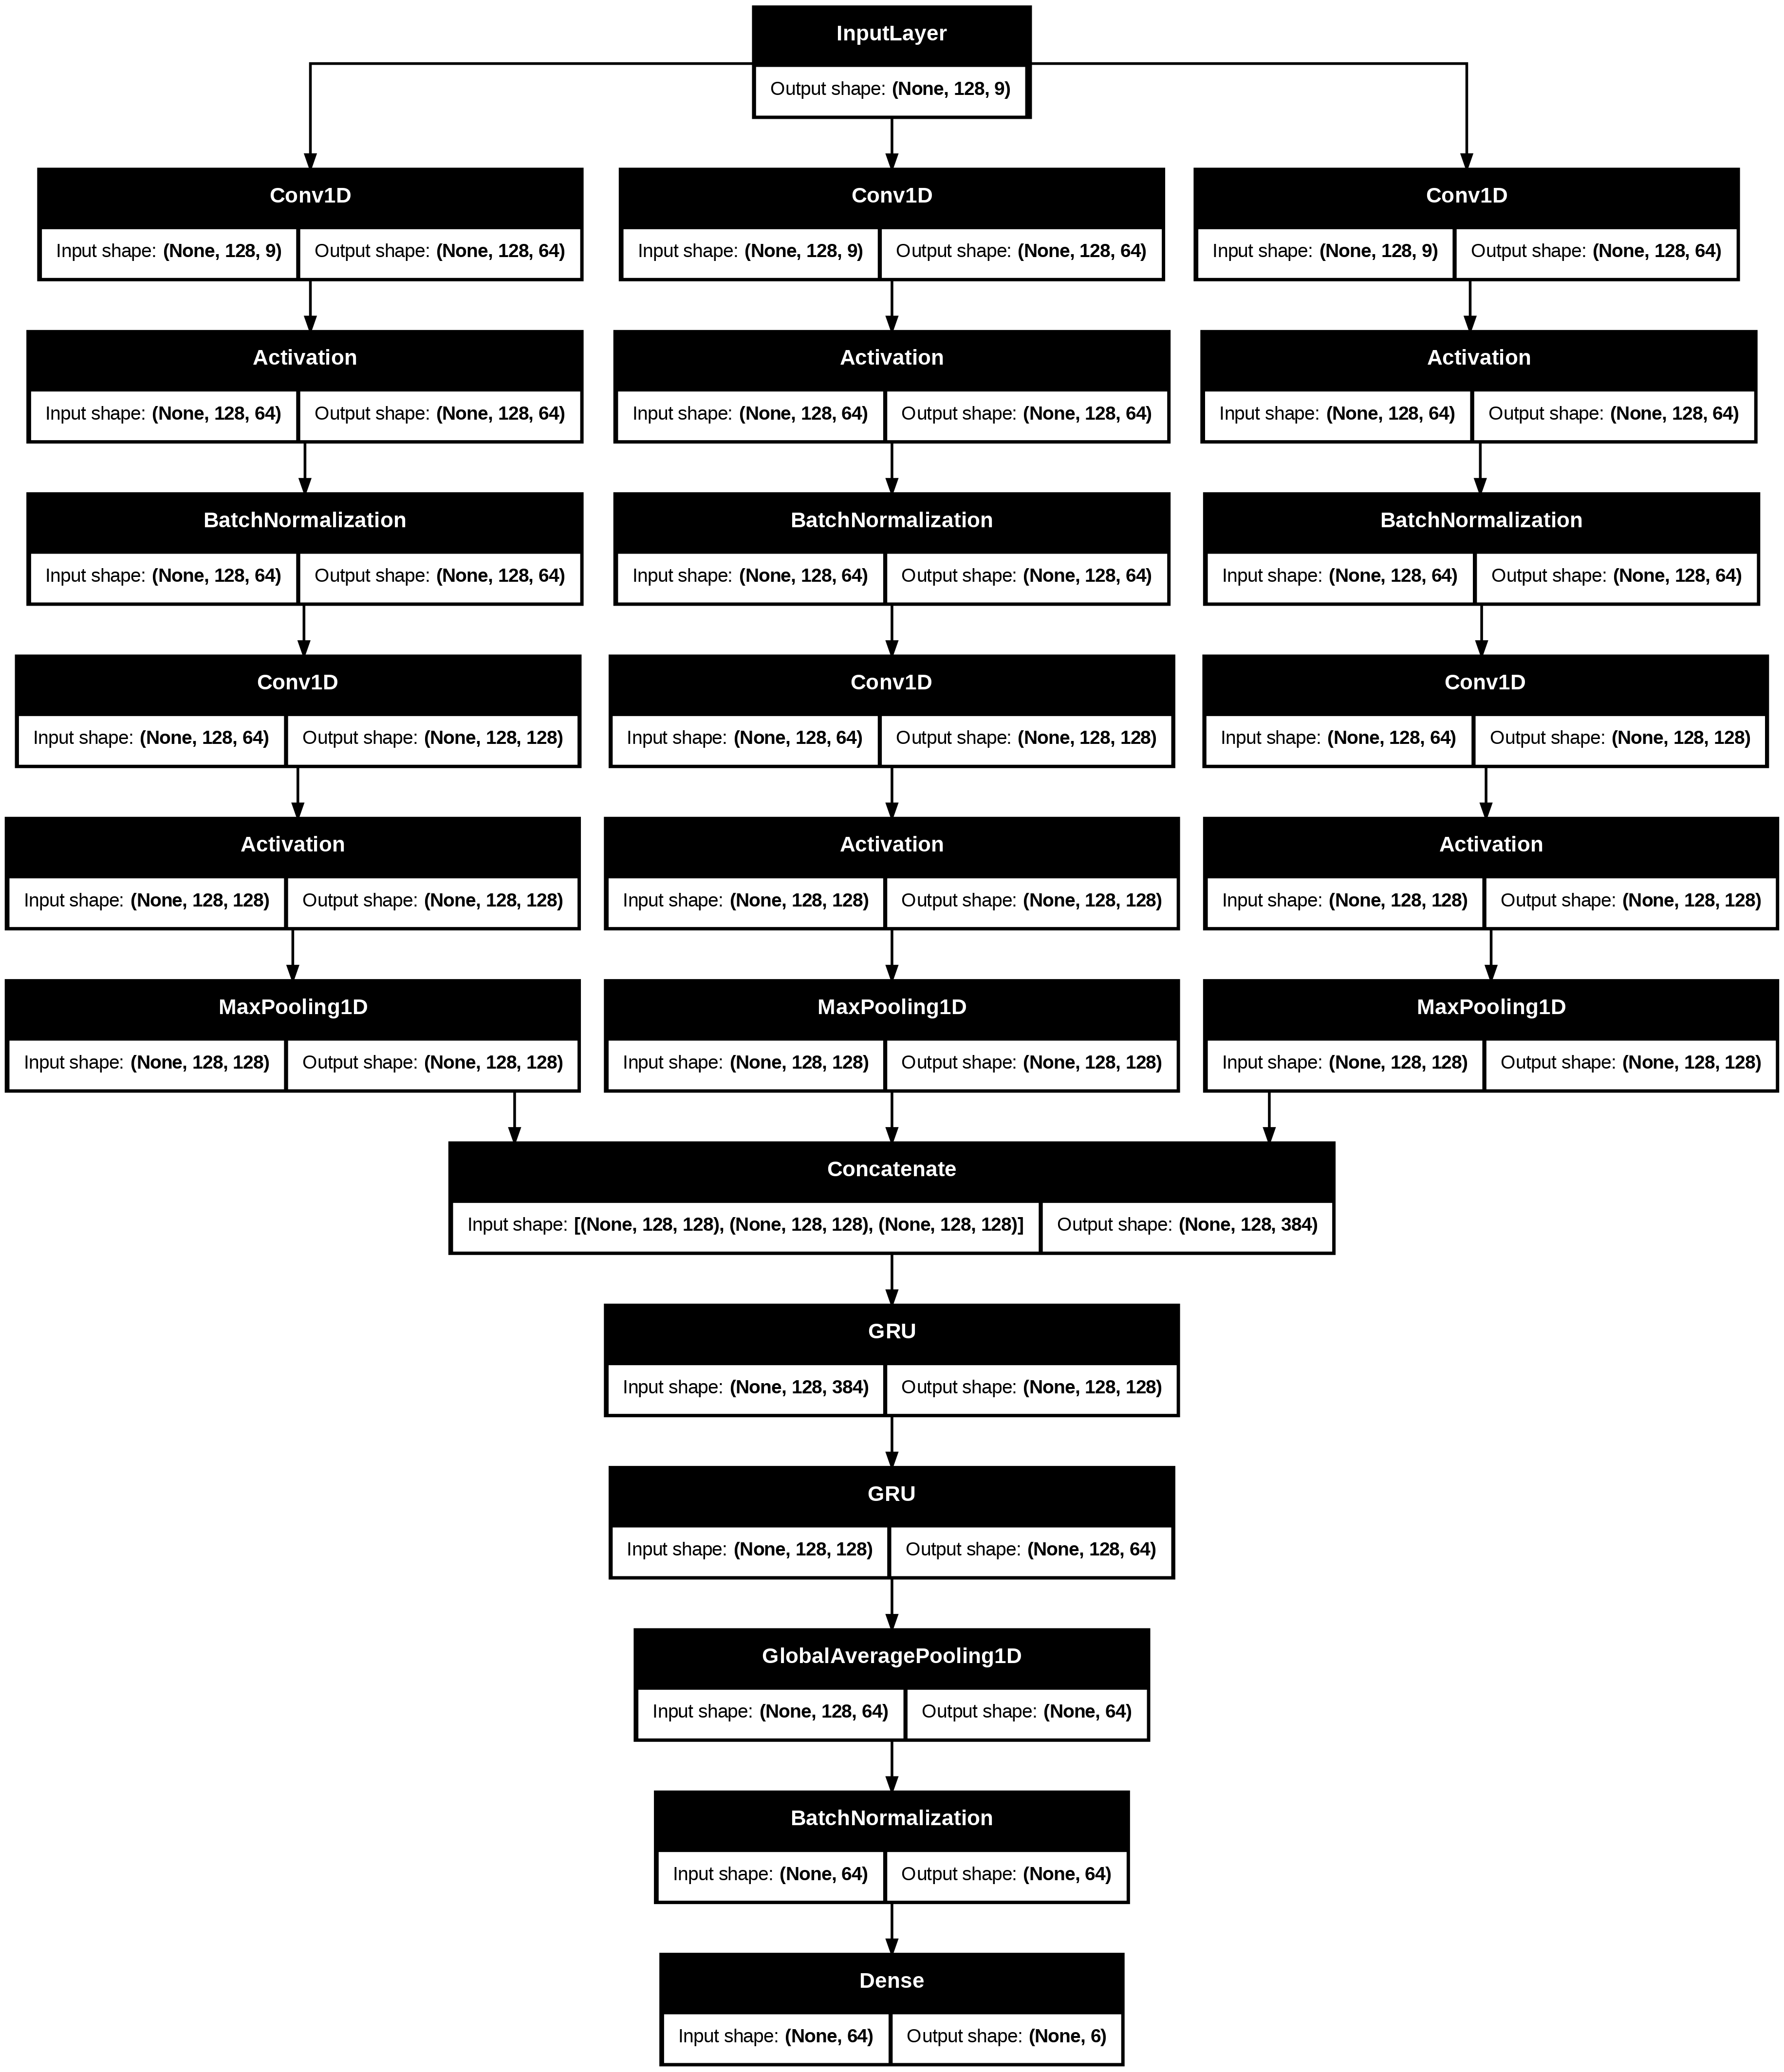

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Callback 설정(학습 중 자동으로 개입)
callbacks = [
    # 가장 성능이 좋은 모델을 파일로 저장
    ModelCheckpoint(
        "UCI_HAR_Multichannel_CNN_GRU_best.keras",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    # 조기 종료 : 더 이상 성능이 좋아지지 않으면 학습 종료
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    # 학습이 정체되면 learning rate 감소
    ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
    )
]

In [ ]:
# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=96,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6090 - sparse_categorical_accuracy: 0.7950
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.94565, saving model to UCI_HAR_Multichannel_CNN_GRU_best.keras

Epoch 1: finished saving model to UCI_HAR_Multichannel_CNN_GRU_best.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.3048 - sparse_categorical_accuracy: 0.8959 - val_loss: 0.9369 - val_sparse_categorical_accuracy: 0.9457 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1264 - sparse_categorical_accuracy: 0.9555
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.94565
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1284 - sparse_categorical_accuracy: 0.9504 - val_loss: 0.4325 - val_sparse_categorical_accuracy: 0.9321 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1127 - sparse_categorical_accuracy: 0.9556
Epoch 3: val_sparse_categorical_accuracy did not improve

In [ ]:
# 모델 평가
model = tf.keras.models.load_model("UCI_HAR_Multichannel_CNN_GRU_best.keras")

# 학습 및 테스트 성능 평가
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 97.01%
Training loss: 0.0653
Test accuracy: 94.13%
Test loss: 0.2638


In [ ]:
# 예측 및 분류 리포트
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9879    0.9939       496
           1     0.9470    0.9490    0.9480       471
           2     0.9333    1.0000    0.9655       420
           3     0.8850    0.8147    0.8484       491
           4     0.8791    0.9023    0.8905       532
           5     1.0000    1.0000    1.0000       537

    accuracy                         0.9413      2947
   macro avg     0.9407    0.9423    0.9411      2947
weighted avg     0.9410    0.9413    0.9407      2947



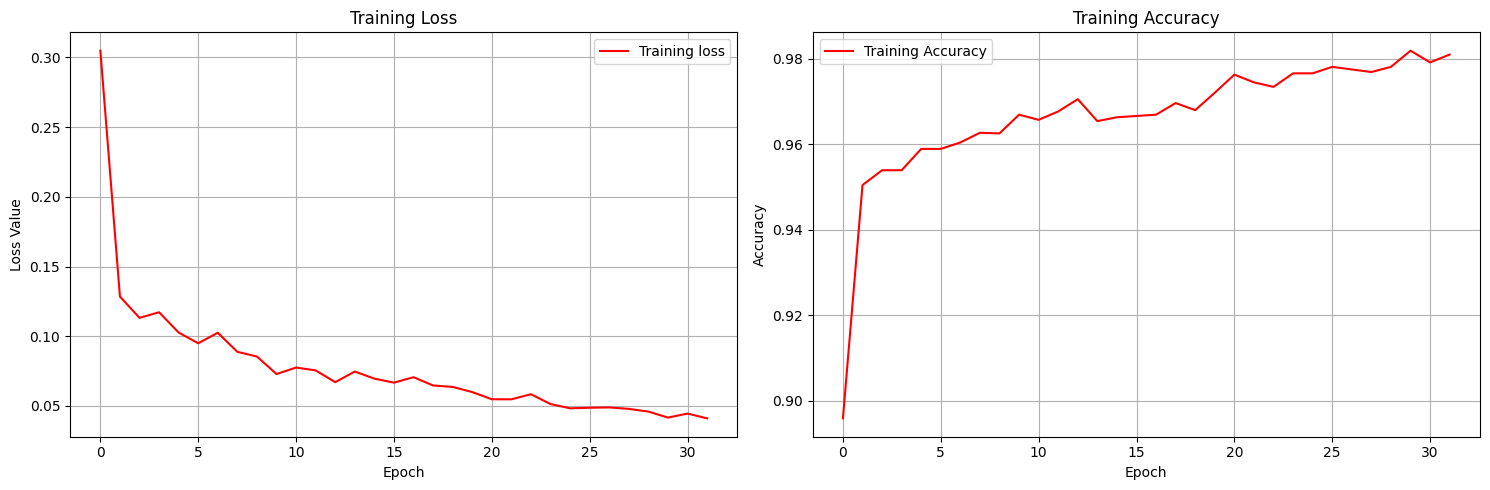

In [ ]:
# 학습 곡선 시각화
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

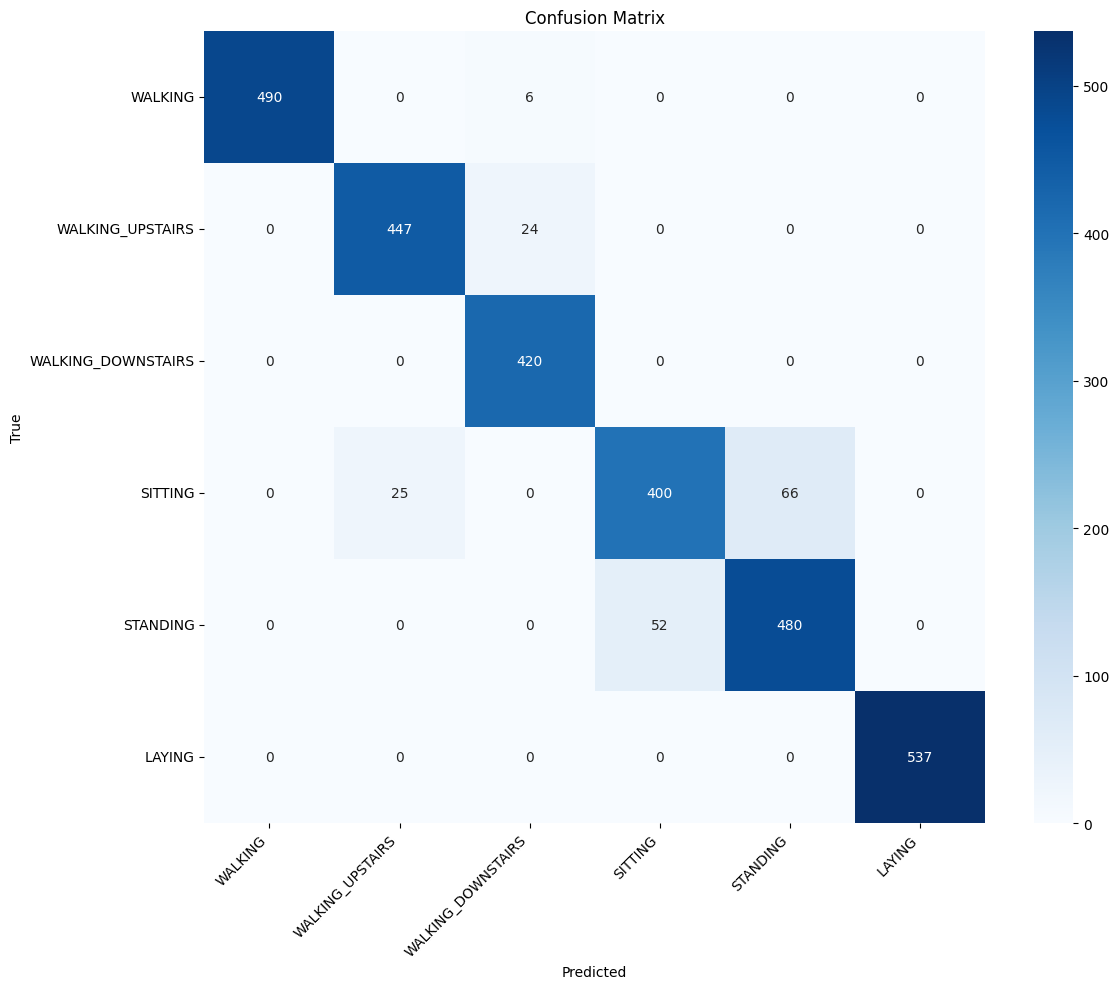

In [ ]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()